## 1. Import Libraries

**Tujuan:** Memuat seluruh library yang dibutuhkan sepanjang proses data understanding ini.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 2. Load Dataset

**Tujuan:** Memuat dataset asli (masih bersih, sebelum tahap data corruption di NB02) sebagai ground truth referensi.

In [4]:
df = pd.read_csv('../data/raw/healthcare-dataset-stroke-data.csv')
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


**Insight:** Dataset berhasil dimuat dengan 5.110 baris, 12 kolom — sesuai ekspektasi.

## 3. Overview Umum

**Tujuan:** Memahami struktur dasar dataset — jumlah baris/kolom, nama kolom, dan tipe data tiap kolom.

In [5]:
print(f"Shape: {df.shape[0]} baris, {df.shape[1]} kolom")
print("\nNama kolom:")
print(df.columns.tolist())
print("\nTipe data tiap kolom:")
print(df.dtypes)

Shape: 5110 baris, 12 kolom

Nama kolom:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Tipe data tiap kolom:
id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object


**Insight:** Dataset terdiri dari X kolom numerik dan Y kolom kategorikal. Tidak ada tipe data yang mencurigakan (semua sudah sesuai ekspektasi: id/age/dst numerik, gender/work_type/dst string).

## 4. Pemeriksaan Missing Value

**Tujuan:** Mengidentifikasi kolom mana saja yang memiliki data kosong (NaN), beserta jumlah dan persentasenya terhadap total data.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct.round(2)
})

missing_summary[missing_summary['Jumlah Missing'] > 0]

,Jumlah Missing,Persentase (%)
bmi,201,3.93


**Insight:** Ditemukan missing value hanya pada kolom `bmi` (~3.93% dari total data). Kolom lain lengkap. Penanganan missing value akan dilakukan di NB03 (setelah tahap data corruption di NB02).

## 5. Statistik Deskriptif

**Tujuan:** Melihat sebaran nilai pada kolom numerik (mean, median, min-max, dst) dan frekuensi tiap kategori pada kolom kategorikal/biner.

In [7]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
df[numeric_cols].describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


In [8]:
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- gender ---
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

--- hypertension ---
hypertension
0    4612
1     498
Name: count, dtype: int64

--- heart_disease ---
heart_disease
0    4834
1     276
Name: count, dtype: int64

--- ever_married ---
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

--- work_type ---
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

--- Residence_type ---
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

--- smoking_status ---
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64



**Insight:**

Dari sisi numerik, usia (`age`) berkisar antara 0.08–82 tahun dengan rata-rata 43.2 tahun — rentang yang wajar untuk data populasi umum. `avg_glucose_level` berkisar 55.1–271.7 mg/dL (rata-rata 106.2), dan `bmi` berkisar 10.3–97.6 (rata-rata 28.9), dengan catatan `bmi` masih memiliki 201 data kosong (count 4.909 dari 5.110) sesuai temuan Section 4.

Dari sisi kategorikal:
- **Gender**: didominasi Female (58.6%) vs Male (41.4%), dengan 1 baris berkategori "Other" (0.02%).
- **Hypertension**: mayoritas pasien (90.3%) tidak memiliki hipertensi, hanya 9.7% yang memiliki.
- **Heart disease**: serupa, 94.6% tidak memiliki penyakit jantung, 5.4% memiliki.
- **Ever married**: 65.6% berstatus menikah, 34.4% belum.
- **Work type**: didominasi Private (57.2%), diikuti Self-employed (16.0%), children (13.4%), Govt_job (12.9%), dan Never_worked yang sangat kecil (0.4%).
- **Residence type**: hampir seimbang antara Urban (50.8%) dan Rural (49.2%).
- **Smoking status**: never smoked paling banyak (37.0%), diikuti kategori Unknown (30.2%), formerly smoked (17.3%), dan smokes (15.4%).

## 6. Analisis Distribusi Target (stroke)

**Tujuan:** Mengetahui proporsi kelas pada target `stroke`, untuk mendeteksi apakah dataset ini imbalanced sejak tahap awal — sebelum masuk ke preprocessing maupun modeling.

Distribusi kelas 'stroke':
Tidak stroke (0): 4861 (95.13%)
Stroke (1)      : 249 (4.87%)


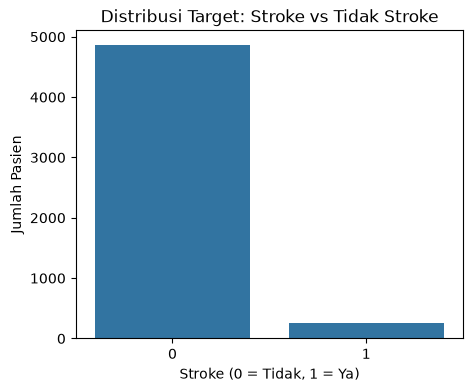

In [9]:
stroke_counts = df['stroke'].value_counts()
stroke_pct = (df['stroke'].value_counts(normalize=True) * 100).round(2)

print("Distribusi kelas 'stroke':")
print(f"Tidak stroke (0): {stroke_counts[0]} ({stroke_pct[0]}%)")
print(f"Stroke (1)      : {stroke_counts[1]} ({stroke_pct[1]}%)")

plt.figure(figsize=(5,4))
sns.countplot(x='stroke', data=df)
plt.title('Distribusi Target: Stroke vs Tidak Stroke')
plt.xlabel('Stroke (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Pasien')
plt.show()

**Insight:**

Dari total 5.110 baris, distribusi kelas `stroke` adalah:
- Tidak stroke (0): 4.861 baris (95.1%)
- Stroke (1): 249 baris (4.9%)

Dataset ini **imbalanced secara signifikan** — rasio hampir 20:1 antara kelas mayoritas dan minoritas. Kondisi ini penting untuk seluruh tahap berikutnya:
1. Saat modeling, model berisiko mengalami **accuracy paradox** — bisa mencapai akurasi >95% hanya dengan selalu memprediksi "tidak stroke", padahal gagal total mendeteksi kasus stroke yang sebenarnya (recall = 0).
2. Karena itu, evaluasi model nantinya wajib menyertakan **Recall, F1-Score, dan Confusion Matrix** — bukan accuracy saja — karena recall langsung mencerminkan kemampuan model mendeteksi pasien berisiko stroke, yang jadi prioritas utama dalam konteks medis.
3. Temuan ini juga akan memengaruhi keputusan preprocessing di tahap selanjutnya (missing value, outlier, feature selection) — setiap keputusan perlu mempertimbangkan dampaknya terhadap 249 kasus minoritas ini, karena kesalahan kecil bisa berdampak proporsional besar pada kelas yang sudah sangat sedikit.

## 7. Rangkuman / Kesimpulan Data Health

**Tujuan:** Merangkum seluruh temuan dari proses data understanding menjadi kesimpulan kondisi data (data health), sebagai dasar keputusan pada tahap data corruption (NB02) dan data cleaning (NB03) berikutnya.

In [10]:
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
print(f"Jumlah id duplikat   : {df['id'].duplicated().sum()}")

Jumlah baris duplikat: 0
Jumlah id duplikat   : 0


**Kesimpulan Data Health:**

Dataset Healthcare Stroke Prediction terdiri dari **5.110 baris dan 12 kolom** (termasuk `id` dan target `stroke`). Secara umum kondisi data **cukup bersih**, dengan rincian sebagai berikut:

1. **Missing value**: Hanya ditemukan pada kolom `bmi` (201 baris, ~3.9%). Kolom lain lengkap 100%.
2. **Duplikat**: Tidak ditemukan baris maupun `id` duplikat (0 dari 5.110).
3. **Konsistensi kategori**: Nilai-nilai kategorikal (`gender`, `work_type`, `Residence_type`, dst) sudah konsisten penulisannya — tidak ada variasi ejaan/kapitalisasi yang ganjil pada tahap ini.
4. **Distribusi fitur**: Sebagian besar fitur numerik (`age`, `avg_glucose_level`, `bmi`) berada pada rentang yang masuk akal secara medis. Beberapa fitur kategorikal/biner menunjukkan proporsi yang tidak seimbang secara alami (`hypertension` 9.7% positif, `heart_disease` 5.4% positif) — ini bukan kesalahan data, melainkan karakteristik alami populasi.
5. **Target variabel (`stroke`)**: Imbalanced signifikan (95.1% vs 4.9%), yang akan memengaruhi strategi evaluasi model di tahap modeling nanti.

**Catatan penting:** Dataset pada notebook ini merepresentasikan kondisi **asli/ground truth** — belum melalui proses apapun. Notebook selanjutnya (`02_data_corruption`) akan secara sengaja memperkenalkan masalah data (duplikat, inkonsistensi, error nilai, missing value tambahan) untuk keperluan simulasi preprocessing sesuai arahan tugas, sebelum dibersihkan kembali pada `03_data_cleaning`.